# Step 1 — Specification

> The full prompt for this step is reproduced verbatim below so the notebook
> is self-contained and reproducible (CLAUDE.md code-style rule).

STEP 1 — Data download & clean returns

Read CLAUDE.md first. Implement ONLY this step, in notebooks/01_data.ipynb.

## Documentation requirement
The FIRST cell of the notebook must be a markdown cell containing this
entire prompt, verbatim, under the title "# Step 1 — Specification".
This applies to every step going forward: each notebook opens with its
full spec, so the notebook is self-contained and reproducible.

## Goal
Download all raw data the system needs, from 2000-01-01 (or earliest
available) to today. Produce clean price and return series, saved to data/.
No modeling, no optimization — data and returns only.

## Assets (7 ETFs)
SPY, VEA, XLE, XLU, IEF, SHY, GLD — daily ADJUSTED closes (dividends
reinvested; critical for bond ETFs where much of the return is yield).
Use yfinance. Auto-adjusted prices (auto_adjust=True).

## Market indicators
- VIX and VIX3M: yfinance (^VIX, ^VIX3M)
- Yield curve spread: FRED series T10Y2Y (use pandas_datareader or direct
  FRED CSV URL; no API key needed)
- Cleveland Fed recession probability: download if freely accessible;
  if the URL/format is unstable, leave a documented placeholder and move on
- CAPE: leave a documented placeholder (manual download from shillerdata.com
  later); do not scrape

## Important known facts (do not "fix" these)
- Each ETF has a different inception date. VEA starts ~2007, others earlier
  (SPY 1993, GLD 2004, IEF/SHY 2002, XLE/XLU 1998). Do NOT truncate
  everything to the latest start. Keep each series from its own start;
  produce a table showing first/last valid date per asset.
- VIX3M may appear under ^VIX3M only from ~2007 too. Fine.

## Outputs (to data/)
1. prices_daily.parquet — adjusted closes, all assets + indicators, one
   column each, business-day index, NaN where not yet listed
2. returns_daily.parquet — simple returns (pct_change) of the 7 ETFs
3. returns_weekly.parquet — weekly returns from Friday-to-Friday adjusted
   closes (resample 'W-FRI', last, then pct_change). These feed covariance
   estimation later (see CLAUDE.md rule 3)
4. A small summary table printed in the notebook: per asset — start date,
   end date, # obs, annualized return, annualized vol, worst day

## Sanity checks (print results clearly)
- No duplicated dates; index sorted
- Missing data: report % NaN per series after inception date; investigate
  anything > 0.5%
- Extreme moves: list any daily return with |r| > 15% (should be ~none for
  these ETFs; if found, inspect — likely a data error)
- Quick eyeball plot: cumulative growth of $1 for the 7 ETFs (log scale)
- Correlation sanity (on weekly returns, full sample): SPY–VEA should be
  ~0.8+; SPY–IEF near zero or negative; SHY near zero with everything.
  Print the 7x7 weekly correlation matrix rounded to 2 decimals.

Keep it simple: plain pandas, short markdown cells explaining each block.


## 0 — Setup

Imports and configuration. Nothing here touches the network yet. We fix the
7-ETF universe, the market-indicator tickers, the sample window, and resolve
the `data/` folder so this notebook runs whether it is launched from the
project root or from `notebooks/`.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path
from datetime import date

# --- Universe (FIXED per CLAUDE.md; SHY is the anchor, still needs data) ---
ETFS = ["SPY", "VEA", "XLE", "XLU", "IEF", "SHY", "GLD"]

# --- Sample window: earliest requested start -> today ---
START = "2000-01-01"
END = date.today().isoformat()   # today; each series still starts at its own inception

# --- Resolve project paths (works from repo root OR from notebooks/) ---
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

print("Sample window :", START, "->", END)
print("Data folder   :", DATA_DIR)
print("ETFs          :", ETFS)

Sample window : 2000-01-01 -> 2026-08-05
Data folder   : c:\Users\LOPEJ533\OneDrive - The Walt Disney Company\Documentación\Berkeley\Python\TrabajoFinal\data
ETFs          : ['SPY', 'VEA', 'XLE', 'XLU', 'IEF', 'SHY', 'GLD']


## 1 — Download from yfinance (ETFs + VIX/VIX3M)

`auto_adjust=True` means the "Close" field is already adjusted for dividends
and splits — this is what we want, especially for the bond ETFs (IEF, SHY)
where most of the total return is coupon income. We keep each series from its
own inception; missing early history is expected, not a bug.

We fetch the 7 ETFs **and** `^VIX`/`^VIX3M` in a **single** `yf.download` call
to minimise requests, wrapped in a retry-with-backoff helper. Yahoo aggressively
rate-limits plain requests, so we route yfinance through a browser-impersonating
`curl_cffi` session (`pip install curl_cffi`) — this is the reliable way to avoid
`YFRateLimitError`. If `curl_cffi` is missing we fall back to the default
session (which may be throttled).

In [2]:
ALL_TICKERS = ETFS + ["^VIX", "^VIX3M"]

# Browser-impersonating session avoids Yahoo's YFRateLimitError.
try:
    from curl_cffi import requests as _cr
    SESSION = _cr.Session(impersonate="chrome")
except Exception as _e:
    print("curl_cffi unavailable, using default session:", _e)
    SESSION = None

def download_close(tickers, start, end, tries=6, pause=20):
    """yf.download of adjusted closes with retry/backoff for Yahoo rate limits."""
    for k in range(tries):
        try:
            df = yf.download(tickers, start=start, end=end, auto_adjust=True,
                             progress=False, threads=False, session=SESSION)
            if not df.empty and "Close" in df.columns.get_level_values(0):
                close = df["Close"]
                if close.dropna(how="all").shape[0] > 0:
                    return close
        except Exception as e:
            print(f"  attempt {k+1}: {type(e).__name__}: {e}")
        wait = pause * (k + 1)
        print(f"  empty/rate-limited; retrying in {wait}s ...")
        time.sleep(wait)
    raise RuntimeError(f"yfinance download failed after {tries} tries")

close_all = download_close(ALL_TICKERS, START, END)
close_all.index = pd.to_datetime(close_all.index)
close_all.index.name = "Date"

adj = close_all[ETFS].copy()   # 7 ETF adjusted closes, in fixed order
assert list(adj.columns) == ETFS, f"Missing/extra ETF columns: {list(adj.columns)}"
print("Adjusted-close panel (ETFs):", adj.shape)
adj.tail(3)

Adjusted-close panel (ETFs): (6687, 7)


Ticker,SPY,VEA,XLE,XLU,IEF,SHY,GLD
Date,,,,,,,
2026-07-31,747.030029,70.620003,59.549999,44.349998,92.631996,81.749001,371.540009
2026-08-03,757.669983,71.040001,58.790001,44.360001,92.820000,81.769997,371.709991
2026-08-04,771.330017,72.220001,58.520000,44.110001,93.250000,81.870003,374.160004


## 2 — Market indicators

Watched, never traded (CLAUDE.md). We collect:

- **VIX / VIX3M** — from yfinance (`^VIX`, `^VIX3M`). VIX3M only begins ~2007.
- **T10Y2Y** — 10y–2y Treasury yield-curve spread, from the FRED CSV endpoint
  (no API key). FRED marks non-observation days with `.`, which we coerce to NaN.
- **Recession probability** — the *literal Cleveland Fed* yield-curve series has
  an unstable URL/format, so per the spec it stays a **documented placeholder**
  (NaN column `CLEV_RECESS_PROB`). As a working stand-in we pull FRED
  `RECPROUSM156N` (Chauvet–Piger *smoothed U.S. recession probability*, monthly)
  into column `RECPRO`. This is **not** the Cleveland Fed series — it is a
  freely-accessible recession-probability indicator we can use until the
  Cleveland Fed source is wired in.
- **CAPE** — **documented placeholder** (NaN column). Manual download from
  shillerdata.com later; we do not scrape.

In [3]:
# --- VIX and VIX3M: already fetched in the single download above ---
vix = close_all[["^VIX", "^VIX3M"]].rename(columns={"^VIX": "VIX", "^VIX3M": "VIX3M"})

def fred_csv(series_id):
    """Read a FRED series from the keyless CSV endpoint -> pandas Series."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    d = pd.read_csv(url, parse_dates=["observation_date"])
    d = d.rename(columns={"observation_date": "Date"}).set_index("Date")
    col = d.columns[0]
    d[col] = pd.to_numeric(d[col], errors="coerce")  # FRED "." -> NaN
    return d[col]

t10y2y = fred_csv("T10Y2Y").rename("T10Y2Y")           # daily yield-curve spread
recpro = fred_csv("RECPROUSM156N").rename("RECPRO")    # monthly recession prob (stand-in)

print("VIX/VIX3M :", vix.shape, "| first VIX3M:", vix["VIX3M"].first_valid_index())
print("T10Y2Y    :", t10y2y.shape, "| range:", t10y2y.index.min().date(), "->", t10y2y.index.max().date())
print("RECPRO    :", recpro.shape, "| range:", recpro.index.min().date(), "->", recpro.index.max().date())

VIX/VIX3M : (6687, 2) | first VIX3M: 2006-07-17 00:00:00
T10Y2Y    : (13091,) | range: 1976-06-01 -> 2026-08-04
RECPRO    : (709,) | range: 1967-06-01 -> 2026-06-01


## 3 — Assemble `prices_daily` on a business-day grid

We join ETFs + indicators onto a single business-day (`Mon–Fri`) index.

Two deliberate choices, both documented so they are not mistaken for bugs:

- The business-day grid **includes market holidays**, so every series shows NaN
  on those ~9–10 days/year. That is a property of a regular calendar grid, not
  missing data. The missing-data sanity check in §6 measures gaps against SPY's
  *actual* trading days to avoid this holiday noise.
- `RECPRO` is monthly, so it only has a value on the first business day of each
  month and NaN elsewhere. `CLEV_RECESS_PROB` and `CAPE` are all-NaN
  placeholders. Forward-filling these is a *modeling* decision deferred to later
  steps — Step 1 stores the raw, point-in-time values only.

In [4]:
frames = [adj, vix, t10y2y, recpro]
# The FRED series (T10Y2Y from 1976, RECPRO from 1967) predate our window, so
# clip the grid's lower bound to START — otherwise prices_daily would carry
# decades of rows where every ETF/VIX is NaN. Upper bound = latest observation.
lo = max(min(f.dropna(how="all").index.min() for f in frames), pd.Timestamp(START))
hi = max(f.dropna(how="all").index.max() for f in frames)
bidx = pd.bdate_range(lo, hi)   # Mon-Fri grid (holidays included -> NaN)

prices = pd.concat(frames, axis=1).reindex(bidx)
prices["CLEV_RECESS_PROB"] = np.nan   # documented placeholder (Cleveland Fed)
prices["CAPE"] = np.nan               # documented placeholder (Shiller)
prices.index.name = "Date"

col_order = ETFS + ["VIX", "VIX3M", "T10Y2Y", "RECPRO", "CLEV_RECESS_PROB", "CAPE"]
prices = prices[col_order]
print("prices_daily:", prices.shape)
print("columns:", list(prices.columns))
prices.tail(3)

prices_daily: (6937, 13)
columns: ['SPY', 'VEA', 'XLE', 'XLU', 'IEF', 'SHY', 'GLD', 'VIX', 'VIX3M', 'T10Y2Y', 'RECPRO', 'CLEV_RECESS_PROB', 'CAPE']


,SPY,VEA,XLE,XLU,IEF,SHY,GLD,VIX,VIX3M,T10Y2Y,RECPRO,CLEV_RECESS_PROB,CAPE
Date,,,,,,,,,,,,,
2026-07-31,747.030029,70.620003,59.549999,44.349998,92.631996,81.749001,371.540009,15.99,NaN,0.47,NaN,NaN,NaN
2026-08-03,757.669983,71.040001,58.790001,44.360001,92.820000,81.769997,371.709991,15.86,NaN,0.45,NaN,NaN,NaN
2026-08-04,771.330017,72.220001,58.520000,44.110001,93.250000,81.870003,374.160004,16.50,NaN,0.43,NaN,NaN,NaN


## 4 — Returns

- **Daily** and **weekly** returns are computed from the *native* trading-day
  adjusted closes (`adj`), NOT from the holiday-padded grid above — otherwise
  holidays would inject spurious NaN/zero returns.
- **Weekly** uses Friday-to-Friday closes (`resample('W-FRI').last()` then
  `pct_change()`). These feed covariance estimation later; CLAUDE.md rule 3
  requires weekly (not daily) returns for covariance because daily data
  understates SPY–VEA correlation (international close-time lag).

In [5]:
returns_daily = adj.pct_change()

weekly_px = adj.resample("W-FRI").last()
returns_weekly = weekly_px.pct_change()

print("returns_daily :", returns_daily.shape)
print("returns_weekly:", returns_weekly.shape)
returns_weekly.tail(3)

returns_daily : (6687, 7)
returns_weekly: (1388, 7)


C:\Users\LOPEJ533\AppData\Local\Temp\ipykernel_8744\1967367871.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_daily = adj.pct_change()


Ticker,SPY,VEA,XLE,XLU,IEF,SHY,GLD
Date,,,,,,,
2026-07-24,-0.005866,0.000144,0.033634,0.024795,-0.008632,-0.001708,0.009473
2026-07-31,0.010962,0.013054,-0.001174,-0.041910,-0.000860,0.001833,-0.000968
2026-08-07,0.032529,0.022656,-0.017296,-0.005411,0.006672,0.001480,0.007052


## 5 — Save outputs to `data/`

Three parquet files: the daily price/indicator panel, daily ETF returns, and
weekly ETF returns.

In [6]:
p1 = DATA_DIR / "prices_daily.parquet"
p2 = DATA_DIR / "returns_daily.parquet"
p3 = DATA_DIR / "returns_weekly.parquet"

prices.to_parquet(p1)
returns_daily.to_parquet(p2)
returns_weekly.to_parquet(p3)

for p in (p1, p2, p3):
    print(f"saved {p.name:24s} {p.stat().st_size/1024:8.1f} KB")

saved prices_daily.parquet        401.5 KB
saved returns_daily.parquet       455.3 KB
saved returns_weekly.parquet       98.0 KB


## 6 — Per-asset summary table

Per ETF: first/last valid date, number of observations, **geometric**
annualized return (252 trading days), annualized volatility, and worst single
day. Different start dates are expected (inception dates differ) — we do not
truncate to a common window.

In [7]:
rows = []
for t in ETFS:
    s = adj[t].dropna()
    r = returns_daily[t].dropna()
    n = len(r)
    ann_ret = (1 + r).prod() ** (252 / n) - 1 if n else np.nan
    ann_vol = r.std() * np.sqrt(252)
    rows.append({
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "n_obs": len(s),
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "worst_day": r.min(),
    })
summary = pd.DataFrame(rows, index=ETFS)
summary_fmt = summary.copy()
for c in ["ann_return", "ann_vol", "worst_day"]:
    summary_fmt[c] = (summary_fmt[c] * 100).round(2).astype(str) + "%"
print(summary_fmt.to_string())
summary

          start         end  n_obs ann_return ann_vol worst_day
SPY  2000-01-03  2026-08-04   6686      8.38%  19.29%   -10.94%
VEA  2007-07-26  2026-08-04   4786      5.33%  21.56%   -11.18%
XLE  2000-01-03  2026-08-04   6686      8.57%  28.76%   -20.14%
XLU  2000-01-03  2026-08-04   6686      8.18%  19.23%   -11.36%
IEF  2002-07-30  2026-08-04   6042      3.56%    6.8%    -2.51%
SHY  2002-07-30  2026-08-04   6042      1.99%   1.52%    -0.66%
GLD  2004-11-18  2026-08-04   5460     10.34%  18.19%   -10.27%


,start,end,n_obs,ann_return,ann_vol,worst_day
SPY,2000-01-03,2026-08-04,6686,0.083829,0.192899,-0.109424
VEA,2007-07-26,2026-08-04,4786,0.053272,0.215558,-0.111803
XLE,2000-01-03,2026-08-04,6686,0.085679,0.287636,-0.201412
XLU,2000-01-03,2026-08-04,6686,0.081793,0.192295,-0.113577
IEF,2002-07-30,2026-08-04,6042,0.035628,0.067962,-0.025072
SHY,2002-07-30,2026-08-04,6042,0.019917,0.015208,-0.006566
GLD,2004-11-18,2026-08-04,5460,0.103399,0.181931,-0.102742


## 7 — Sanity checks

Mandatory per CLAUDE.md rule 7. Any surprise here means "suspect a data bug
before anything else".

### 7a — Index integrity: no duplicate dates, sorted

In [8]:
dupe = prices.index.duplicated().any()
sorted_ok = prices.index.is_monotonic_increasing
print("duplicated dates :", dupe)
print("index sorted     :", sorted_ok)
assert not dupe and sorted_ok, "Index integrity check FAILED"
print("OK — index is unique and sorted.")

duplicated dates : False
index sorted     : True
OK — index is unique and sorted.


### 7b — Missing data after inception

Measured against **SPY's actual trading days** (SPY trades every US equity
session in-sample), so holidays on the business-day grid do not masquerade as
missing data. We flag any tradable series with > 0.5% gaps.

Expected-sparse columns are reported separately and NOT flagged: `RECPRO`
(monthly), and the `CLEV_RECESS_PROB` / `CAPE` placeholders (all NaN).

In [9]:
trading_days = adj["SPY"].dropna().index   # US equity trading calendar (in-sample)

tradable = ETFS + ["VIX", "VIX3M", "T10Y2Y"]
report = {}
for c in tradable:
    s = prices[c]
    fv = s.first_valid_index()
    if fv is None:
        report[c] = np.nan
        continue
    cal = trading_days[trading_days >= fv]          # days we EXPECT a value
    miss = s.reindex(cal).isna().mean() * 100
    report[c] = round(miss, 3)

miss_pct = pd.Series(report, name="pct_nan_after_inception")
print(miss_pct.to_string())
flagged = miss_pct[miss_pct > 0.5]
if len(flagged):
    print("\n>0.5% missing — inspect:")
    print(flagged.to_string())
    # Expected explanation: T10Y2Y follows the FRED/bond-market calendar, which
    # differs from SPY's equity calendar (bond-only closures like Columbus Day /
    # Veterans Day, plus FRED "." non-observations). This is a calendar mismatch,
    # not a data gap — benign for a watched indicator.
    if set(flagged.index) <= {"T10Y2Y"}:
        print("  -> T10Y2Y only: FRED/bond-calendar vs equity-calendar mismatch. Benign.")
else:
    print("\nAll tradable series <= 0.5% missing after inception. OK.")

print("\nExpected-sparse / placeholder columns (not flagged):")
for c in ["RECPRO", "CLEV_RECESS_PROB", "CAPE"]:
    n_valid = prices[c].notna().sum()
    print(f"  {c:18s} valid obs = {n_valid}")

SPY       0.000
VEA       0.000
XLE       0.000
XLU       0.000
IEF       0.000
SHY       0.000
GLD       0.000
VIX       0.000
VIX3M     0.238
T10Y2Y    0.718

>0.5% missing — inspect:
T10Y2Y    0.718
  -> T10Y2Y only: FRED/bond-calendar vs equity-calendar mismatch. Benign.

Expected-sparse / placeholder columns (not flagged):
  RECPRO             valid obs = 226
  CLEV_RECESS_PROB   valid obs = 0
  CAPE               valid obs = 0


### 7c — Extreme daily moves (|r| > 15%)

For broad ETFs these should be essentially nonexistent; any hit is inspected as
a likely data error.

In [10]:
extreme = returns_daily[(returns_daily.abs() > 0.15)]
hits = extreme.stack()
if len(hits):
    print(f"{len(hits)} extreme move(s) found:")
    print((hits * 100).round(2).astype(str).add("%").to_string())
    # Verdict: cross-check the dates. All should land on known crisis sessions
    # (2008 GFC, Mar-2020 COVID crash / oil price war). If so -> real moves.
    yrs = sorted({d.year for d, _ in hits.index})
    crisis_years = {2008, 2020}
    if set(yrs) <= crisis_years:
        print(f"\n  -> all on crisis-year sessions {yrs} (GFC / COVID). Real moves, not data errors.")
    else:
        print(f"\n  -> years {yrs} include non-crisis dates; INSPECT for data errors.")
else:
    print("No daily |return| > 15% for any ETF. OK.")

5 extreme move(s) found:
Date        Ticker
2008-10-13  VEA        15.33%
            XLE        16.47%
2008-10-28  XLE        15.25%
2020-03-09  XLE       -20.14%
2020-03-24  XLE        16.04%

  -> all on crisis-year sessions [2008, 2020] (GFC / COVID). Real moves, not data errors.


### 7d — Cumulative growth of \$1 (log scale)

Adjusted closes already reinvest dividends, so growth of \$1 = price / first
valid price. Each ETF starts at its own inception.

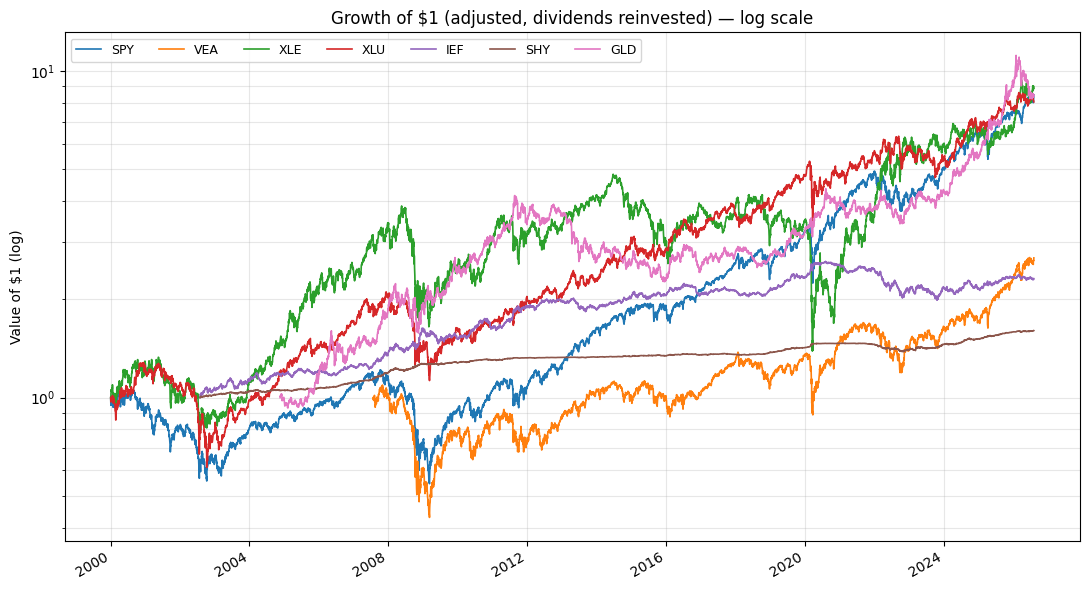

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for t in ETFS:
    s = adj[t].dropna()
    (s / s.iloc[0]).plot(ax=ax, label=t, linewidth=1.2)
ax.set_yscale("log")
ax.set_title("Growth of $1 (adjusted, dividends reinvested) — log scale")
ax.set_ylabel("Value of $1 (log)")
ax.set_xlabel("")
ax.legend(ncol=7, fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### 7e — Weekly correlation matrix (full sample)

CLAUDE.md rule 7 targets: SPY–VEA ~0.8+; SPY–IEF near zero or negative; SHY
near zero with everything.

One nuance on the last target: SHY is near zero with the **risk assets**
(equities + gold), but it correlates strongly with **IEF** — both are US
Treasuries, so that pair is *expected* to be high and is not a rule-7 failure.
The check below separates the two so a healthy SHY–IEF number doesn't look like
a violation.

In [12]:
corr = returns_weekly[ETFS].corr().round(2)
print(corr.to_string())

print("\nKey checks:")
print(f"  SPY-VEA = {corr.loc['SPY','VEA']:.2f}  (expect ~0.8+)")
print(f"  SPY-IEF = {corr.loc['SPY','IEF']:.2f}  (expect ~0 or negative)")
print(f"  SHY-IEF = {corr.loc['SHY','IEF']:.2f}  (both Treasuries -> expected high, NOT a violation)")
risk = ["SPY", "VEA", "XLE", "XLU", "GLD"]
shy_risk = corr.loc["SHY", risk]
print(f"  SHY vs risk assets {risk}:")
print(f"     min={shy_risk.min():.2f}, max={shy_risk.max():.2f}  (expect near 0)")

Ticker   SPY   VEA   XLE   XLU   IEF   SHY   GLD
Ticker                                          
SPY     1.00  0.88  0.64  0.59 -0.22 -0.20  0.08
VEA     0.88  1.00  0.68  0.57 -0.17 -0.14  0.19
XLE     0.64  0.68  1.00  0.47 -0.26 -0.20  0.18
XLU     0.59  0.57  0.47  1.00  0.08  0.01  0.19
IEF    -0.22 -0.17 -0.26  0.08  1.00  0.78  0.21
SHY    -0.20 -0.14 -0.20  0.01  0.78  1.00  0.22
GLD     0.08  0.19  0.18  0.19  0.21  0.22  1.00

Key checks:
  SPY-VEA = 0.88  (expect ~0.8+)
  SPY-IEF = -0.22  (expect ~0 or negative)
  SHY-IEF = 0.78  (both Treasuries -> expected high, NOT a violation)
  SHY vs risk assets ['SPY', 'VEA', 'XLE', 'XLU', 'GLD']:
     min=-0.20, max=0.22  (expect near 0)


## 8 — Visual relationship between the 7 ETFs

Two views of how the ETFs move together, both on **weekly returns**:

1. **Correlation heatmap** — diverging palette (green = positive, red = negative)
   centred at 0.
2. **Pairwise scatter matrix** — lower triangle, with each series' histogram on
   the diagonal.

Both use the **common overlapping window** (only weeks where all 7 ETFs have a
return, i.e. from VEA's ~2007 inception onward) so the scatter clouds correspond
exactly to the heatmap numbers. Note this differs slightly from the full-sample
pairwise matrix in §7e, which uses each pair's own overlap.

Common weekly sample: 2007-08-03 -> 2026-08-07 (n=993)


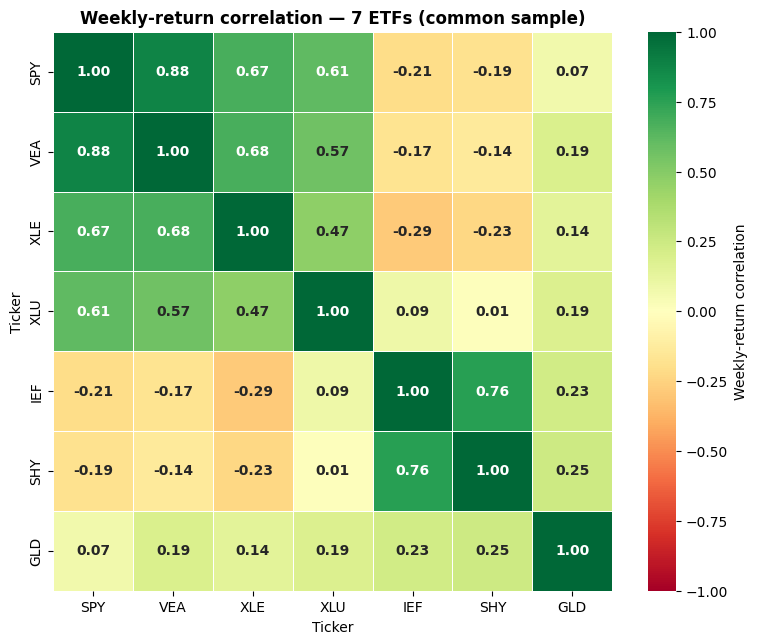

In [13]:
import seaborn as sns

# Common window: keep weeks where ALL 7 ETFs have a return (youngest is VEA ~2007).
rw = returns_weekly[ETFS].dropna()
corr_common = rw.corr()
print(f"Common weekly sample: {rw.index.min().date()} -> {rw.index.max().date()} (n={len(rw)})")

# 1) Correlation heatmap (RdYlGn: green=+, red=-, centered at 0)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_common, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Weekly-return correlation"},
            annot_kws={"fontsize": 10, "fontweight": "bold"}, ax=ax)
ax.set_title("Weekly-return correlation — 7 ETFs (common sample)", fontweight="bold")
plt.tight_layout()
plt.show()

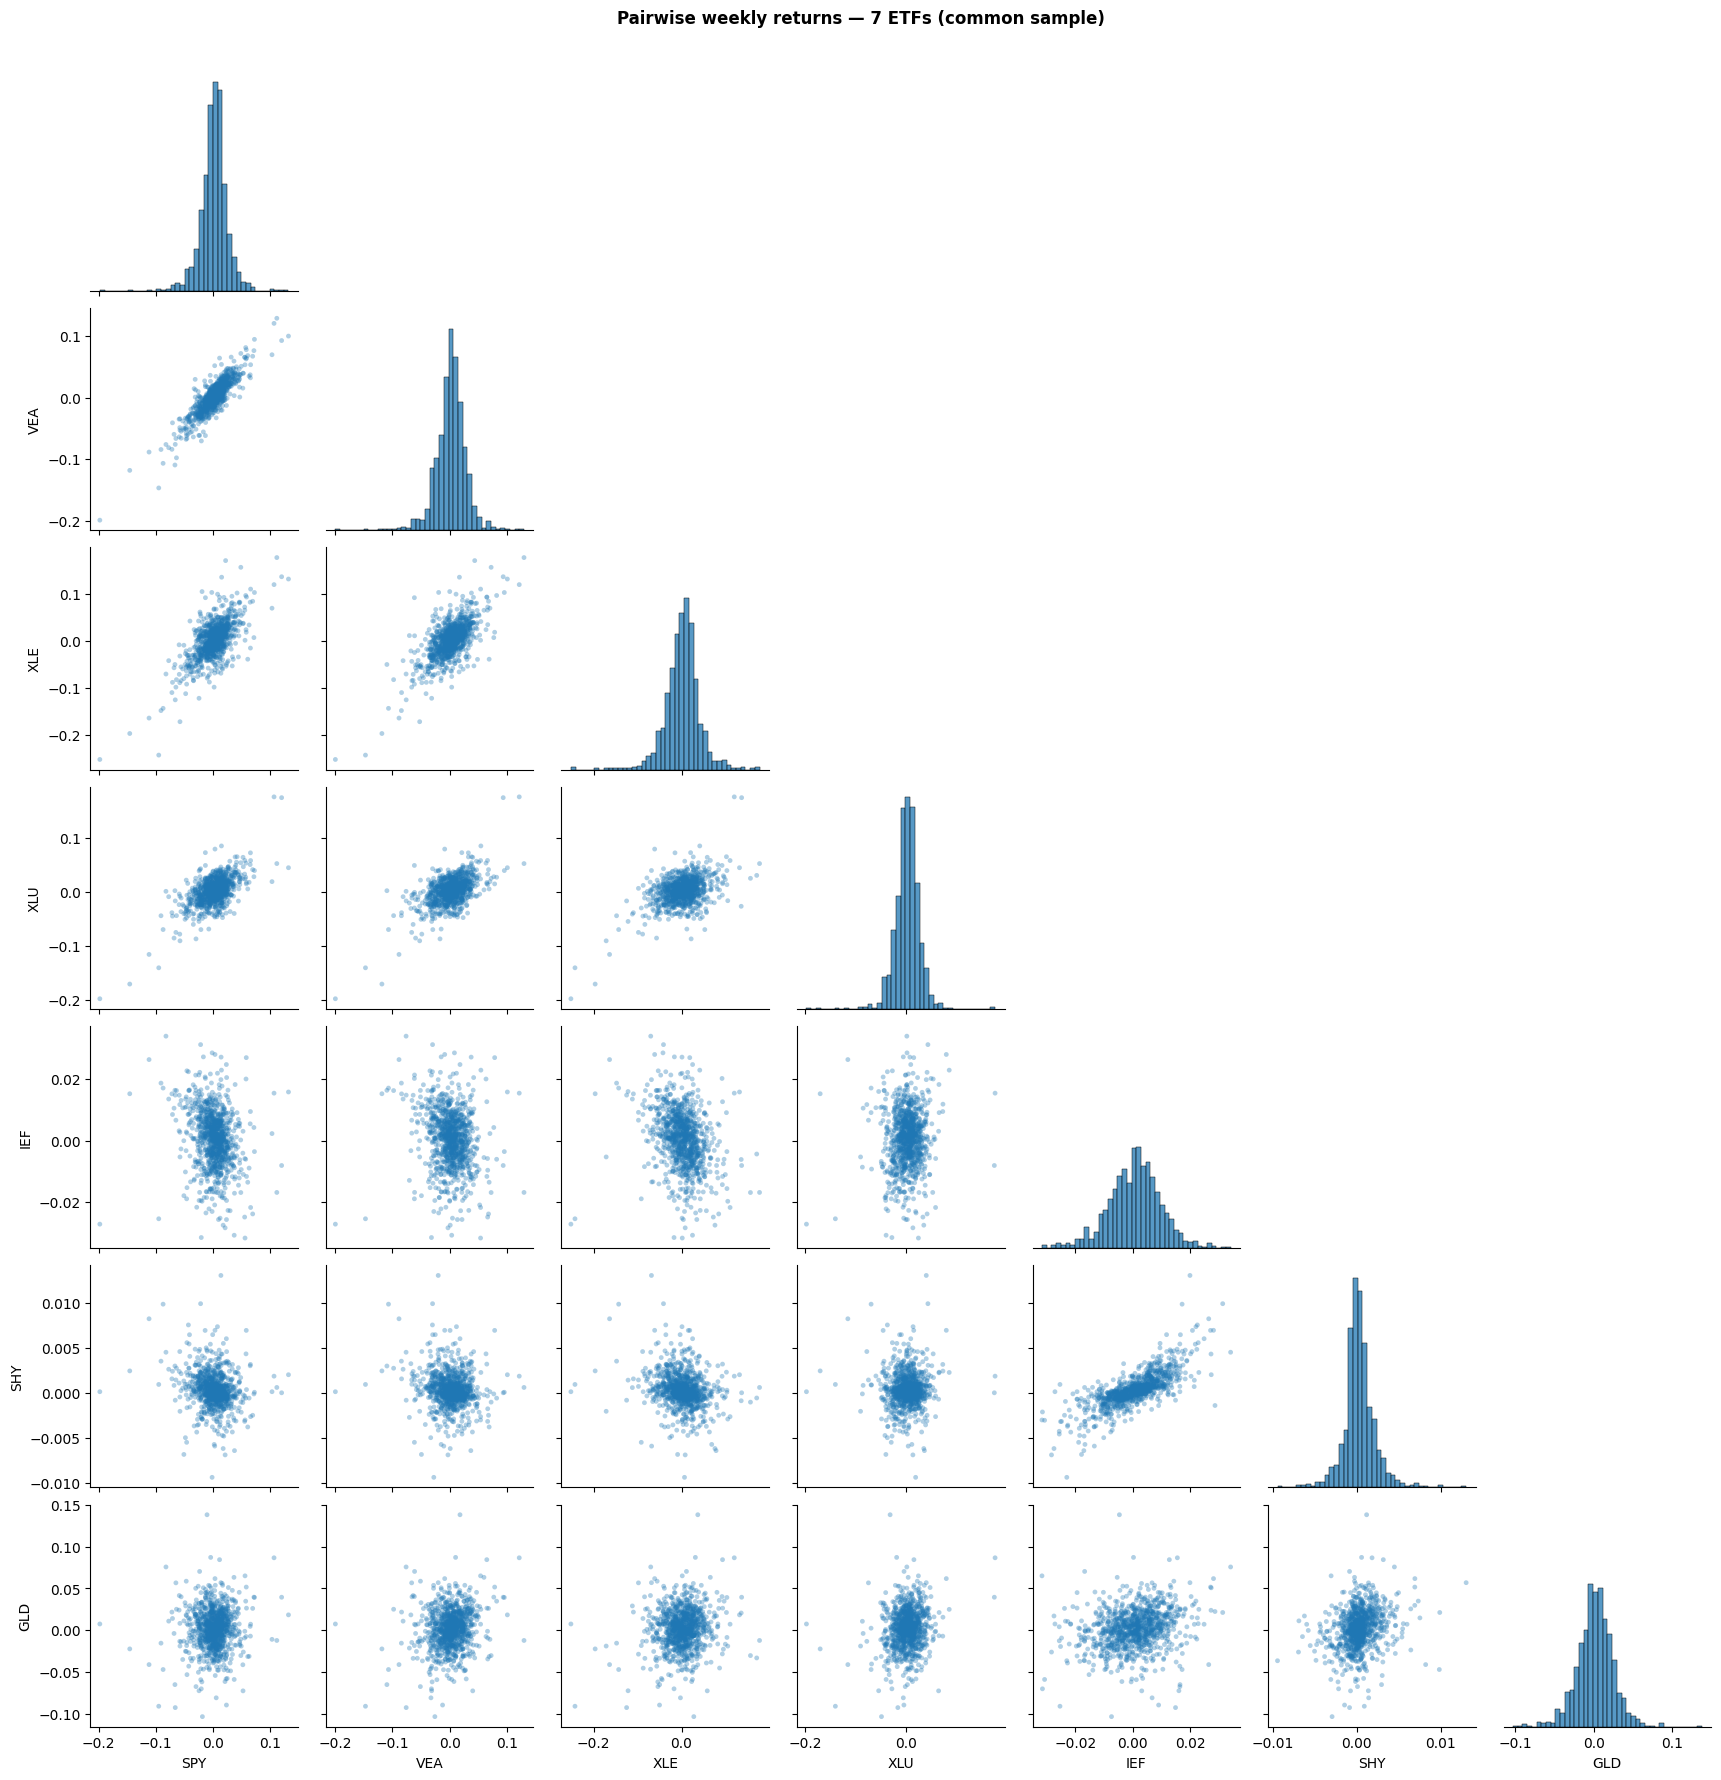

In [14]:
# 2) Pairwise scatter matrix (lower triangle; histogram on the diagonal)
g = sns.pairplot(rw, corner=True, diag_kind="hist",
                 plot_kws={"alpha": 0.35, "s": 12, "edgecolor": "none"},
                 diag_kws={"bins": 40})
g.figure.suptitle("Pairwise weekly returns — 7 ETFs (common sample)",
                  fontweight="bold", y=1.02)
plt.show()

## Done — Step 1 complete

Produced in `data/`: `prices_daily.parquet`, `returns_daily.parquet`,
`returns_weekly.parquet`. No modeling performed. Open items carried forward:
`CLEV_RECESS_PROB` (Cleveland Fed) and `CAPE` remain documented placeholders
for a later stable/manual ingestion; `RECPRO` is available as a working
recession-probability stand-in.